# Fitting Marginals and Copulas to the VMLS Portfolio

## GSE 544 - Homework 5, Part 1

This notebook fits **Student-$t$ marginals** to each of the 19 risky assets in the VMLS portfolio, applies the **Probability Integral Transform (PIT)**, and compares two copula models, **Gaussian** and **Student-$t$**, on a four-asset subset (stocks 1, 2, 3, 10).

The central question: does the Gaussian copula adequately capture the **joint tail behavior** of financial returns, or does the $t$-copula do better? We make this cost visible through simulation and scatter matrix comparisons.

**Data:** `data/vmls_portfolio_returns.csv` - first 2000 rows (training set), 19 risky assets.

**Four-asset sample:** stocks 1, 2, 3, 10 (0-indexed: `[0, 1, 2, 9]`)

In [23]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gamma as gamfunc

sns.set(style="whitegrid")

## Data

Daily returns for 20 assets (19 risky stocks + 1 risk-free) over 2500 trading days. 
We work exclusively on the **training set** (first 2000 returns) and exclude the 
risk-free asset, leaving a $(2000 \times 19)$ return matrix $R$.

=== Dataset Overview ===
Full dataset : 2500 trading days, 20 assets (19 risky + 1 risk-free)
Training set : 2000 trading days, 19 risky assets (risk-free excluded)
Four-asset sample : ['Stock 1', 'Stock 2', 'Stock 3', 'Stock 10']

Return statistics (all 19 risky assets):
         Stock 1    Stock 2    Stock 3    Stock 4    Stock 5    Stock 6    Stock 7    Stock 8    Stock 9   Stock 10   Stock 11   Stock 12   Stock 13   Stock 14   Stock 15   Stock 16   Stock 17   Stock 18   Stock 19
count  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000  2000.0000
mean      0.0005    -0.0001     0.0003     0.0006     0.0006     0.0001     0.0004     0.0004     0.0003     0.0002     0.0003     0.0002     0.0002     0.0007     0.0006     0.0008     0.0004     0.0006     0.0004
std       0.0269     0.0393     0.0200     0.0287     0.0159     0.0209     0.0190

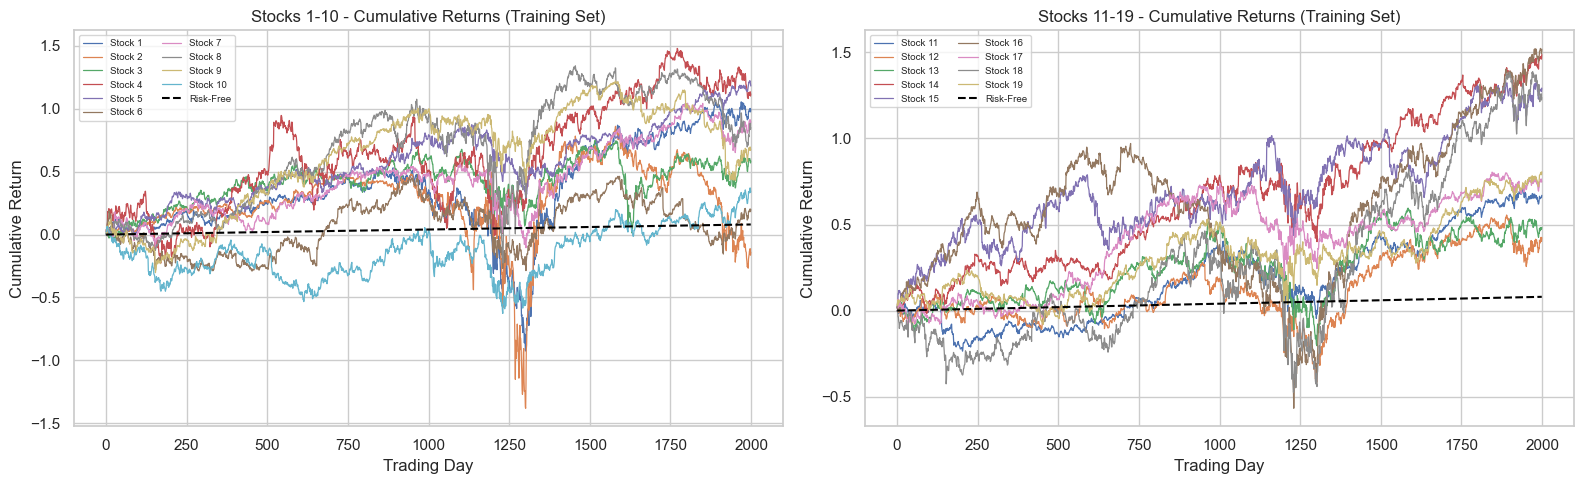

In [24]:
# Load data - training set: first 2000 rows, 19 risky assets (risk-free excluded)
returns_all = pd.read_csv("data/vmls_portfolio_returns.csv").to_numpy()
R = returns_all[:2000, :19]
R_rf = returns_all[:2000, 19]   # risk-free asset
p = R.shape[1]
asset_names = [f"Stock {j+1}" for j in range(p)]

# Four-asset sample (0-indexed: stocks 1, 2, 3, 10)
SAMPLE = [0, 1, 2, 9]
sample_names = [asset_names[j] for j in SAMPLE]

# Dataset overview
df_returns = pd.DataFrame(R, columns=asset_names)
print("=== Dataset Overview ===")
print(f"Full dataset : 2500 trading days, 20 assets (19 risky + 1 risk-free)")
print(f"Training set : {R.shape[0]} trading days, {R.shape[1]} risky assets (risk-free excluded)")
print(f"Four-asset sample : {sample_names}")
print(f"\nReturn statistics (all 19 risky assets):")
print(df_returns.describe().round(4).to_string())

# Plot cumulative returns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for j in range(10):
    axes[0].plot(np.cumsum(R[:, j]), lw=0.9, label=asset_names[j])
for j in range(10, p):
    axes[1].plot(np.cumsum(R[:, j]), lw=0.9, label=asset_names[j])

# Overlay risk-free on both panels
for ax in axes:
    ax.plot(np.cumsum(R_rf), lw=1.5, color="black", linestyle="--", label="Risk-Free")
    ax.set_xlabel("Trading Day")
    ax.set_ylabel("Cumulative Return")
    ax.legend(fontsize=7, ncol=2, loc="upper left")

axes[0].set_title("Stocks 1-10 - Cumulative Returns (Training Set)")
axes[1].set_title("Stocks 11-19 - Cumulative Returns (Training Set)")
plt.tight_layout()
plt.show()

## Part (a) - Student-$t$ Marginals

We fit a Student-$t$ distribution to each of the 19 risky assets using maximum likelihood estimation via `scipy.stats.t.fit()`, which returns three parameters per asset:

- $\nu$ (degrees of freedom) - controls tail heaviness; smaller $\nu$ = fatter tails
- $\mu$ (location) - center of the distribution  
- $\sigma$ (scale) - spread of the distribution

A Gaussian distribution corresponds to $\nu \to \infty$; values of $\nu < 5$ indicate **very fat tails**, meaning extreme returns are far more likely than a normal distribution would predict. We fit all 19 assets and print the summary for our four-asset sample: stocks 1, 2, 3, and 10.

In [25]:
# Fit Student-t marginals to all 19 assets
marginals = [stats.t.fit(R[:, j]) for j in range(p)]  # (df, loc, scale) for each asset

# Print summary for four-asset sample
print("=== Student-t Marginal Fits - Four-Asset Sample ===")
print(f"{'Asset':<12} {'df (ν)':>10} {'loc (μ)':>12} {'scale (σ)':>12}")
print("-" * 48)
for j in SAMPLE:
    df_t, loc, scale = marginals[j]
    print(f"{asset_names[j]:<12} {df_t:>10.4f} {loc:>12.6f} {scale:>12.6f}")

# Full df summary across all 19
nu_all = np.array([m[0] for m in marginals])
print(f"\n=== Degrees of Freedom Summary (all 19 assets) ===")
print(f"min={nu_all.min():.2f}  median={np.median(nu_all):.2f}  "
      f"mean={nu_all.mean():.2f}  max={nu_all.max():.2f}")
print(f"Assets with ν < 5: {(nu_all < 5).sum()}/19")

=== Student-t Marginal Fits - Four-Asset Sample ===
Asset            df (ν)      loc (μ)    scale (σ)
------------------------------------------------
Stock 1          1.7976     0.000376     0.011484
Stock 2          1.3446    -0.000181     0.010552
Stock 3          3.1187     0.000763     0.012203
Stock 10         3.9784     0.000277     0.014511

=== Degrees of Freedom Summary (all 19 assets) ===
min=1.34  median=3.12  mean=3.11  max=4.60
Assets with ν < 5: 19/19


### Analysis

The fitted Student-$t$ parameters for the four-asset sample are shown in the table above. 
All four assets have $\nu < 5$, confirming **very fat tails** across the entire sample. 
**Stock 2 is the fattest-tailed** asset with $\nu = 1.34$, while **Stock 10 is the lightest-tailed** 
with $\nu = 3.98$, though still far from Gaussian behavior ($\nu \to \infty$).

### What this means in practice

A degrees-of-freedom value this low has real consequences for risk. Under a normal distribution, 
a $5\sigma$ return is essentially impossible, it would occur once every several billion trading days. 
Under a Student-$t$ with $\nu \approx 1.3$ (Stock 2), that same extreme move is orders of magnitude 
more likely. This is the mathematical signature of **crash risk**: the fat tails tell us that large 
single-day losses are not rare flukes, they are a structural feature of these return distributions.

Furthermore, with **19/19 assets having $\nu < 5$**, this is not isolated to one volatile stock. 
Every asset in the portfolio exhibits this behavior, which means any joint model we build must 
respect fat-tailed marginals. A Gaussian marginal assumption would systematically **underestimate 
tail risk** for every single asset in the portfolio. This matters not just at the individual asset level, but for the **joint model** as well. If each asset's marginal already has fat tails, the copula we place on top must also capture the tendency 
for multiple assets to experience extreme moves *simultaneously*. A Gaussian copula, despite being 
paired with fat-tailed marginals, has **zero asymptotic tail dependence**, meaning it will always 
underestimate the probability that several assets crash together, which is precisely when portfolio 
risk is most dangerous.

## Part (b) - PITs and the Empirical Scatter Matrix

With Student-$t$ marginals fitted to each asset, we now apply the **Probability Integral Transform (PIT)**:

$$u_j = F_j(r_j)$$

where $F_j$ is the fitted Student-$t$ CDF for asset $j$. If the marginal fits well, each transformed 
column $u_j$ should be approximately $\text{Uniform}(0, 1)$. We clip the result to $[10^{-6}, 1 - 10^{-6}]$ 
to keep $\Phi^{-1}$ and $t^{-1}$ finite for downstream copula fitting.

The key insight of the PIT is that it **strips away the marginal behavior** of each asset, leaving 
only the dependence structure between assets - which is exactly what a copula models. We visualize 
this with a $4 \times 4$ scatter matrix for stocks 1, 2, 3, 10:

- **Diagonal panels** - histograms of each $u_j$, checking for approximate uniformity
- **Off-diagonal panels** - pairwise scatters of $(u_j, u_k)$, revealing where dependence concentrates

This empirical scatter matrix is the **benchmark** that any fitted copula must reproduce.

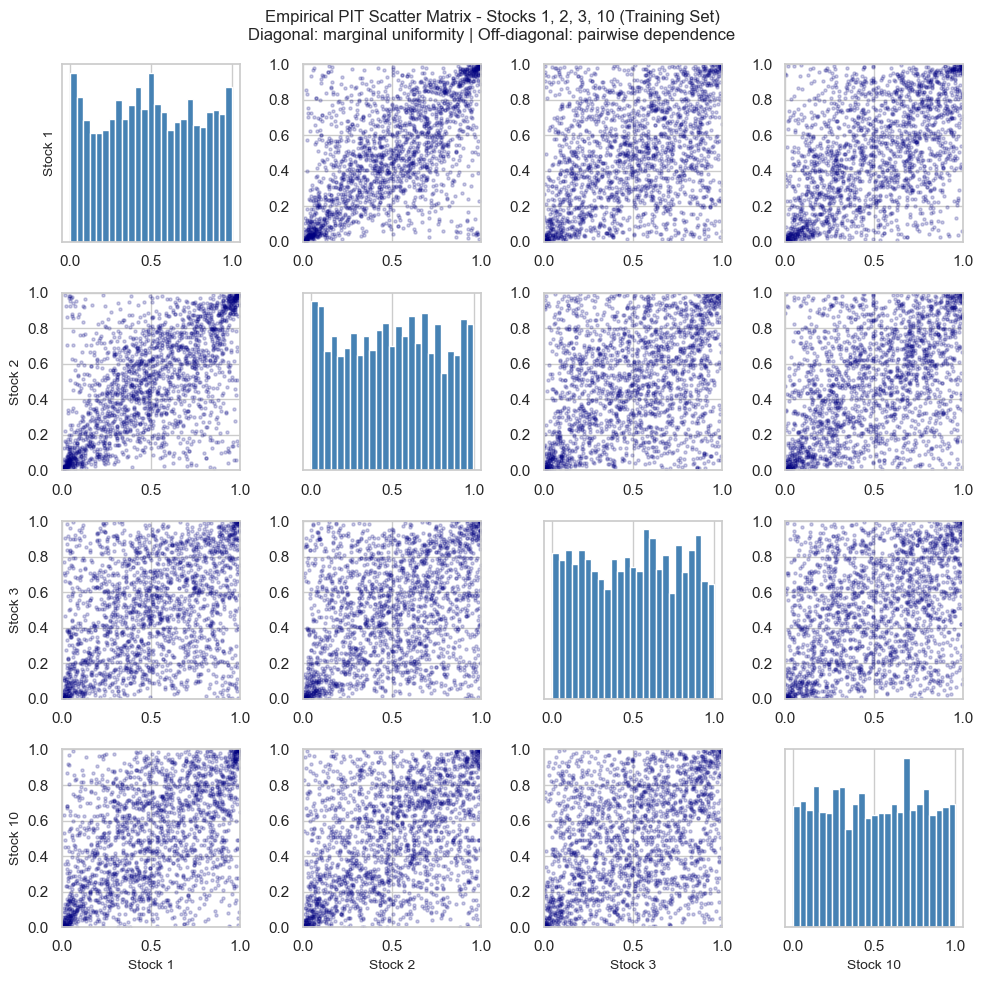

In [26]:
# Apply PIT to all 19 assets using fitted marginals
U = np.column_stack([stats.t.cdf(R[:, j], *marginals[j]) for j in range(p)])
U = np.clip(U, 1e-6, 1 - 1e-6)

# 4x4 empirical PIT scatter matrix for four-asset sample
m = len(SAMPLE)
fig, axes = plt.subplots(m, m, figsize=(10, 10))

for a in range(m):
    for b in range(m):
        ax = axes[a, b]
        ja, jb = SAMPLE[a], SAMPLE[b]
        if a == b:
            # Diagonal: marginal uniformity histogram
            ax.hist(U[:, ja], bins=25, color="steelblue", edgecolor="white")
            ax.set_yticks([])
        else:
            # Off-diagonal: pairwise PIT scatter
            ax.scatter(U[:, jb], U[:, ja], s=5, alpha=0.2, color="navy")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        if a == m - 1: ax.set_xlabel(sample_names[b], fontsize=10)
        if b == 0:     ax.set_ylabel(sample_names[a], fontsize=10)

fig.suptitle("Empirical PIT Scatter Matrix - Stocks 1, 2, 3, 10 (Training Set)\n"
             "Diagonal: marginal uniformity | Off-diagonal: pairwise dependence",
             fontsize=12)
fig.tight_layout()
plt.show()

### Analysis

The diagonal histograms are **approximately uniform** for all four assets, confirming that the 
fitted Student-$t$ marginals are capturing each asset's individual return distribution well - 
the PIT is doing its job of stripping away marginal behavior.

In the off-diagonal panels, the dependence is clearly **not uniform across the unit square**. 
Most notably, there is visible mass concentration in the **bottom-left corner** (0,0) and 
**top-right corner** (1,1) of the pairwise scatters - meaning assets tend to experience extreme 
low returns together and extreme high returns together simultaneously. This corner clustering is 
the empirical signature of **tail dependence**: when one asset crashes, the others are more likely 
to crash as well.

This empirical scatter is the benchmark our fitted copulas must reproduce. A good copula model 
must not only respect the uniform margins on the diagonal, but also **replicate the corner mass** 
in the off-diagonal panels - particularly the bottom-left, which represents the joint crash 
scenario most relevant to portfolio risk.

## Part (c) - Gaussian Copula

A **Gaussian copula** captures dependence through a single correlation matrix $P$. We map 
the PIT scores to normal scores via $z = \Phi^{-1}(u)$ and estimate $P$ as the sample 
correlation matrix of those normal scores. A small eigenvalue floor is applied to ensure 
$P$ remains positive definite.

The **entire dependence structure** of a Gaussian copula lives in $P$ and there are no tail 
parameters. We fit this on the four-asset subset (stocks 1, 2, 3, 10).

In [27]:
# Extract four-asset PIT scores
U4 = U[:, SAMPLE]

# Map PIT scores to normal scores
Z4 = stats.norm.ppf(U4)

# Estimate correlation matrix with eigenvalue floor for positive definiteness
P_gauss = np.corrcoef(Z4, rowvar=False)
ev, V = np.linalg.eigh(P_gauss)
P_gauss = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
d = np.sqrt(np.diag(P_gauss))
P_gauss = P_gauss / np.outer(d, d)
chol_gauss = np.linalg.cholesky(P_gauss)

# Print the correlation matrix
print("=== Gaussian Copula - 4×4 Correlation Matrix (Stocks 1, 2, 3, 10) ===")
print(f"\n{'':>10}", end="")
for name in sample_names:
    print(f"{name:>10}", end="")
print()
for i, name in enumerate(sample_names):
    print(f"{name:<10}", end="")
    for j in range(len(SAMPLE)):
        print(f"{P_gauss[i, j]:>10.4f}", end="")
    print()

print(f"\nCondition number: {np.linalg.cond(P_gauss):.2f}")

=== Gaussian Copula - 4×4 Correlation Matrix (Stocks 1, 2, 3, 10) ===

             Stock 1   Stock 2   Stock 3  Stock 10
Stock 1       1.0000    0.6603    0.4179    0.5360
Stock 2       0.6603    1.0000    0.3928    0.4678
Stock 3       0.4179    0.3928    1.0000    0.4073
Stock 10      0.5360    0.4678    0.4073    1.0000

Condition number: 7.40


### Analysis

The fitted Gaussian copula is fully described by the $4 \times 4$ correlation matrix $P$ above. 
All pairwise correlations are positive and moderate-to-strong, with the **Stock 1 - Stock 2 pair 
showing the strongest dependence** ($\rho = 0.66$) and the **Stock 2 - Stock 3 pair the weakest** 
($\rho = 0.39$). The low condition number of 7.40 confirms $P$ is well-conditioned and numerically 
stable.

This single matrix is the **entire dependence structure** of the Gaussian copula and there are no 
additional parameters. Notably, there is no tail parameter, which means the Gaussian copula assigns 
the same dependence strength across the entire distribution, from the center all the way to the 
extremes. As we saw in Part (b), the empirical data tells a different story. Dependence 
**concentrates in the corners**, something $P$ alone cannot encode.

## Part (d) - Student-$t$ Copula

A **Student-$t$ copula** extends the Gaussian copula by adding a degrees of freedom parameter 
$\nu$ that controls joint tail dependence. The full parameter set is $(P, \nu)$, where $P$ is 
the correlation matrix and $\nu$ governs how much excess mass sits in the joint tails.

Unlike the Gaussian case, there is no closed-form solution - we fit both $P$ and $\nu$ jointly 
via maximum likelihood using `scipy.optimize.minimize`.

In [30]:
# t-copula log-likelihood function
def t_copula_nll(params, U):
    nu = params[0]
    if nu < 2.01:
        return 1e10
    m = U.shape[1]
    
    # Map PIT scores to t-scores
    T = stats.t.ppf(U, df=nu)
    
    # Estimate correlation matrix from t-scores
    P = np.corrcoef(T, rowvar=False)
    ev, V = np.linalg.eigh(P)
    P = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
    d = np.sqrt(np.diag(P))
    P = P / np.outer(d, d)
    
    # Log-likelihood of multivariate t minus sum of univariate t log-likelihoods
    try:
        chol = np.linalg.cholesky(P)
        T_std = np.linalg.solve(chol, T.T).T
        log_det = 2 * np.sum(np.log(np.diag(chol)))
        
        nll = 0
        for i in range(len(U)):
            # Multivariate t log-density
            quad = T_std[i] @ T_std[i]
            log_mv = (np.log(gamfunc((nu + m) / 2)) - np.log(gamfunc(nu / 2)) 
                      - (m / 2) * np.log(nu * np.pi) 
                      - 0.5 * log_det 
                      - ((nu + m) / 2) * np.log(1 + quad / nu))
            
            # Subtract univariate t log-densities
            log_univ = np.sum(stats.t.logpdf(T[i], df=nu))
            nll -= (log_mv - log_univ)
        return nll
    except np.linalg.LinAlgError:
        return 1e10

# Fit t-copula via MLE
result = minimize(t_copula_nll, x0=[4.0], args=(U4,),
                  method="Nelder-Mead", options={"xatol": 1e-4, "fatol": 1e-4})

nu_hat = result.x[0]

# Recover correlation matrix at optimal nu
T4 = stats.t.ppf(U4, df=nu_hat)
P_t = np.corrcoef(T4, rowvar=False)
ev, V = np.linalg.eigh(P_t)
P_t = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
d = np.sqrt(np.diag(P_t))
P_t = P_t / np.outer(d, d)
chol_t = np.linalg.cholesky(P_t)

print(f"=== t-Copula Fit ===")
print(f"Fitted copula degrees of freedom: nu_hat = {nu_hat:.4f}")
print(f"\nMarginal degrees of freedom (Part a):")
for j in SAMPLE:
    print(f"  {asset_names[j]}: nu = {marginals[j][0]:.4f}")
print(f"\nt-Copula correlation matrix P:")
print(f"\n{'':>10}", end="")
for name in sample_names:
    print(f"{name:>10}", end="")
print()
for i, name in enumerate(sample_names):
    print(f"{name:<10}", end="")
    for j in range(len(SAMPLE)):
        print(f"{P_t[i, j]:>10.4f}", end="")
    print()

=== t-Copula Fit ===
Fitted copula degrees of freedom: nu_hat = 3.9881

Marginal degrees of freedom (Part a):
  Stock 1: nu = 1.7976
  Stock 2: nu = 1.3446
  Stock 3: nu = 3.1187
  Stock 10: nu = 3.9784

t-Copula correlation matrix P:

             Stock 1   Stock 2   Stock 3  Stock 10
Stock 1       1.0000    0.6855    0.4414    0.5474
Stock 2       0.6855    1.0000    0.4119    0.4716
Stock 3       0.4414    0.4119    1.0000    0.4404
Stock 10      0.5474    0.4716    0.4404    1.0000


### Analysis

The fitted $t$-copula has $\hat{\nu} = 3.99$, which is **higher than most of the marginal 
degrees of freedom** from Part (a) (Stock 1: 1.80, Stock 2: 1.34, Stock 3: 3.12, Stock 10: 3.98). 
This is expected and not a contradiction - the marginal $\nu$'s and the copula $\hat{\nu}$ are 
measuring fundamentally different things.

The marginal $\nu$'s describe how fat each asset's **individual** return distribution is. 
The copula $\hat{\nu}$ describes the heaviness of the **joint** tail dependence after the 
marginals have been stripped away via the PIT. Once the PIT removes each asset's individual 
tail behavior, the residual dependence structure is somewhat less extreme than any single 
marginal - hence the higher $\hat{\nu}$.

Critically, $\hat{\nu} \approx 4$ is still **finite and small**, meaning the $t$-copula is 
capturing real joint tail dependence in the data. The Gaussian copula implicitly assumes 
$\nu \to \infty$, which forces zero asymptotic tail dependence regardless of the correlation 
matrix. With $\hat{\nu} = 3.99$, the $t$-copula assigns meaningfully higher probability to 
scenarios where multiple assets simultaneously hit their extremes - exactly the joint crash 
behavior visible in the corners of the empirical scatter matrix from Part (b).

## Part (e) - Simulation and Comparison

With both copulas fitted, we now make their differences **visible through simulation**. We draw 
$n = 2000$ uniform-margin observations from each fitted copula (matching the training set size) 
and plot their PIT scatter matrices in the same $4 \times 4$ layout as Part (b).

The three scatter matrices are placed side by side:

- **Empirical** - the benchmark from Part (b), showing the true joint behavior of the data
- **Gaussian simulated** - draws from the fitted Gaussian copula
- **$t$ simulated** - draws from the fitted $t$-copula

The key comparison is the **corner mass**. How much probability sits in the bottom-left (0,0) 
and top-right (1,1) corners of each off-diagonal panel. These corners represent simultaneous 
extreme moves across assets, and whichever copula better reproduces the empirical corner mass 
is the better model for joint tail risk.

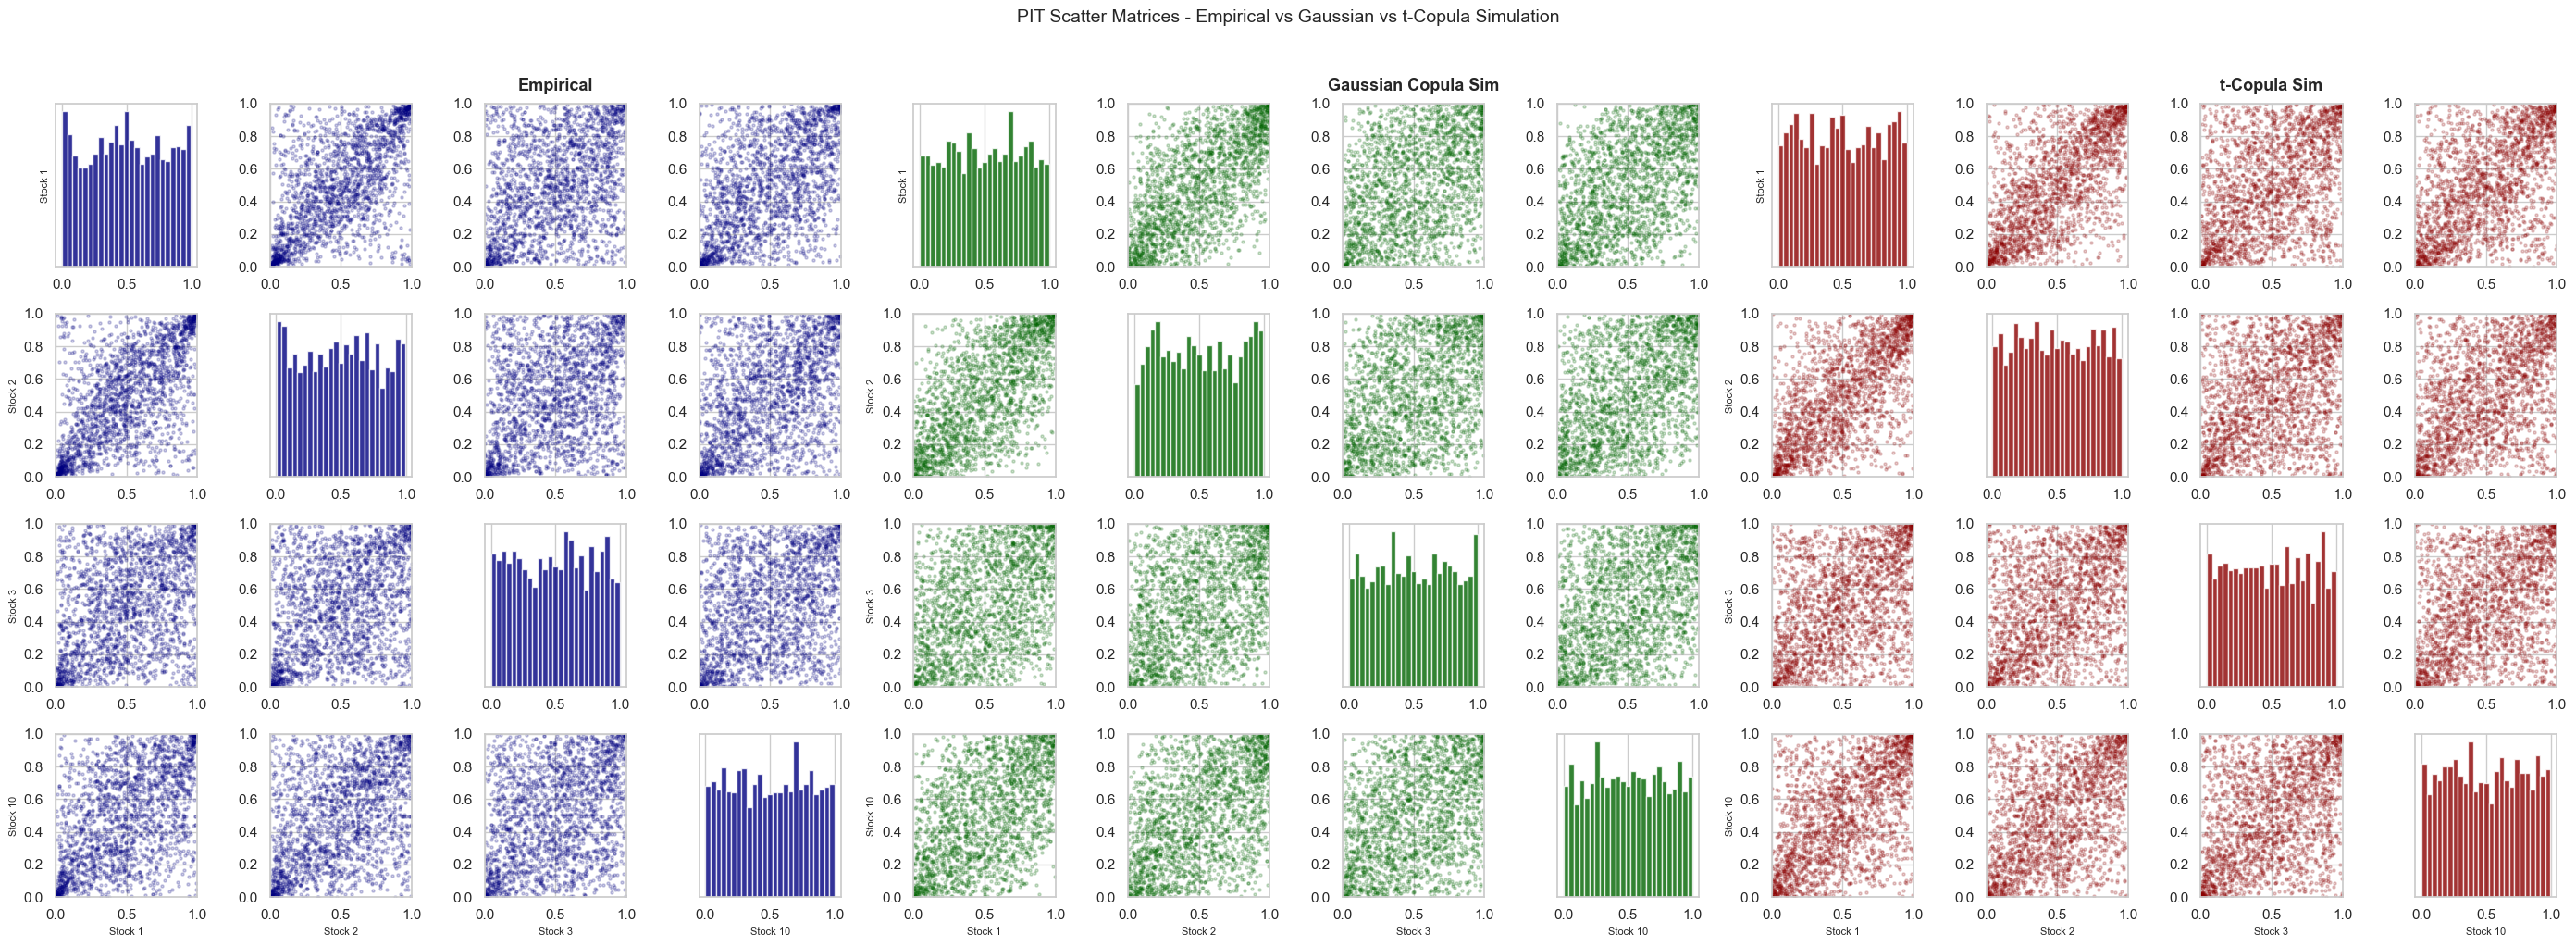

In [29]:
np.random.seed(544)
n_sim = 2000

# --- Simulate from Gaussian copula ---
Z_sim_gauss = np.random.randn(n_sim, len(SAMPLE))
U_sim_gauss = stats.norm.cdf(Z_sim_gauss @ chol_gauss.T)

# --- Simulate from t-copula ---
Z_sim_t = np.random.randn(n_sim, len(SAMPLE))
chi2 = np.random.chisquare(nu_hat, size=n_sim)
T_sim = (Z_sim_t @ chol_t.T) / np.sqrt(chi2 / nu_hat)[:, None]
U_sim_t = stats.t.cdf(T_sim, df=nu_hat)

# --- Plot all three scatter matrices side by side ---
fig, all_axes = plt.subplots(len(SAMPLE), 3 * len(SAMPLE),
                              figsize=(28, 10))

datasets = [
    (U4,          "Empirical",           "navy"),
    (U_sim_gauss, "Gaussian Copula Sim", "darkgreen"),
    (U_sim_t,     "t-Copula Sim",        "darkred"),
]

for col_block, (U_plot, title, color) in enumerate(datasets):
    for a in range(len(SAMPLE)):
        for b in range(len(SAMPLE)):
            ax = all_axes[a, col_block * len(SAMPLE) + b]
            if a == b:
                ax.hist(U_plot[:, a], bins=25, color=color,
                        edgecolor="white", alpha=0.8)
                ax.set_yticks([])
            else:
                ax.scatter(U_plot[:, b], U_plot[:, a],
                           s=5, alpha=0.2, color=color)
                ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            if a == len(SAMPLE) - 1:
                ax.set_xlabel(sample_names[b], fontsize=8)
            if b == 0:
                ax.set_ylabel(sample_names[a], fontsize=8)

# Column block titles
for col_block, (_, title, _) in enumerate(datasets):
    mid = col_block * len(SAMPLE) + len(SAMPLE) // 2
    all_axes[0, mid].set_title(title, fontsize=13, fontweight="bold", pad=10)

fig.suptitle("PIT Scatter Matrices - Empirical vs Gaussian vs t-Copula Simulation",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Analysis

Comparing the three scatter matrices, the diagonal histograms across all three are approximately 
uniform, confirming that both copulas correctly preserve uniform margins by construction.

The key difference is in the **off-diagonal corners**. The empirical scatter (blue) shows clear 
mass concentration in the bottom-left (0,0) and top-right (1,1) corners across all asset pairs, 
reflecting the tendency for stocks to experience extreme moves simultaneously. The Gaussian 
simulated scatter (green) largely fails to reproduce this. Its off-diagonal panels look like 
a diffuse cloud with a diagonal trend but little corner clustering, a direct consequence of 
the Gaussian copula's zero asymptotic tail dependence. The $t$-copula simulated scatter (red) 
visibly reproduces the corner mass much more faithfully, with noticeably more points clustering 
in both corners across all pairs.

This is the **canonical reason finance prefers the $t$-copula**: real asset returns tend to 
crash together and spike together far more often than a Gaussian dependence structure predicts. 
The $t$-copula's finite $\hat{\nu}$ directly encodes this joint tail behavior, while the 
Gaussian copula, regardless of how strong its correlation matrix is, will always underestimate 
the probability of simultaneous extreme moves across a portfolio. In risk management, this 
difference is not cosmetic; it is the difference between correctly pricing tail risk and 
systematically underestimating it.

## Conclusion - Real World Significance

The distinction between the Gaussian and $t$-copula is not merely academic. During the 2008 
financial crisis, many institutions used Gaussian copula models to price and risk-manage 
collateralized debt obligations (CDOs) built on mortgage-backed securities. The Gaussian copula 
assumed that while individual mortgages might default, the **joint probability of mass defaults 
was vanishingly small**. The same zero asymptotic tail dependence we observed in Part (e). 
When housing prices fell nationally and simultaneously, the correlation structure of mortgage 
defaults shifted dramatically into the joint tail, exactly the regime the Gaussian copula was 
structurally blind to. This notebook makes that failure visible in a tractable four-asset 
setting: the empirical data clearly concentrates mass in the corners, the Gaussian copula 
misses it entirely, and the $t$-copula captures it. The lesson is simple but consequential. 
In financial modeling, the tails are not where distributions go to die, they are where the 
real risk lives.